# Trusted Devices and Manual Count EDA

This notebook is an exploratory checkpoint before improving the assignment tasks. It focuses on:

- the relationship between `trusted_unique_devices` and manual counts;
- comparison with other sensor features such as clean/local/raw unique devices;
- weekly and daily trusted-device trends;
- exploratory ideas that can guide improvements to Tasks 1-4.

The analysis is intentionally lightweight and transparent. With only four manual-count windows, every model fit should be treated as directional rather than final.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.load_data import load_all
from src.cleaning import build_quality_mask
from src.task1 import run_task1

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

## Load Data

Use the same loader as the production pipeline so parsing and cleaning assumptions stay aligned with the assignment code.

In [2]:
sessions, facilities, manuals = load_all()

overview = pd.DataFrame(
    [
        {"table": "sessions", "rows": len(sessions), "columns": sessions.shape[1]},
        {"table": "facilities", "rows": len(facilities), "columns": facilities.shape[1]},
        {"table": "manual_counts", "rows": len(manuals), "columns": manuals.shape[1]},
    ]
)
display(overview)

print("Session date range:", sessions["session_start"].min(), "to", sessions["session_start"].max())
print("Manual count windows:", manuals["started"].min(), "to", manuals["started"].max())

,table,rows,columns
0,sessions,2248477,19
1,facilities,10,25
2,manual_counts,8,16


Session date range: 2026-04-20 00:00:01+00:00 to 2026-04-26 23:59:53+00:00
Manual count windows: 2026-04-23 13:00:00+00:00 to 2026-04-24 15:00:00+00:00


In [3]:
active_sensors = (
    facilities.loc[facilities["box_macs"].astype(str) != "[]", [
        "facility_num", "facility_name", "latitude", "longitude", "box_mac_list", "frame_count", "is_active"
    ]]
    .sort_values("facility_num")
)

manual_summary = (
    manuals.groupby(["facility_num", "facility_name", "started", "duration"], as_index=False)
    .agg(manual_total_count=("count", "sum"), categories=("category", lambda s: ", ".join(sorted(s.unique()))))
    .sort_values(["facility_num", "started"])
)

display(active_sensors)
display(manual_summary)

,facility_num,facility_name,latitude,longitude,box_mac_list,frame_count,is_active
0,66330,GB-LVO-DD-08003,53.404,-2.986,[001e42297beb],2,1
1,66331,GB-LVO-DD-08005,53.404,-2.986,[001e422b4f39],2,1
2,66332,GB-LVO-DD-08007,53.403,-2.987,[001e422a1a4b],2,1
3,66333,GB-LVO-DD-08009,53.403,-2.987,[001e422b3bdc],2,1
4,66335,GB-LVO-DD-08013,53.404,-2.988,[001e4235f6c9],2,1
5,66336,GB-LVO-DD-08015,53.405,-2.988,[001e4234ed04],2,1
6,66338,GB-LVO-DD-08019,53.405,-2.984,[001e42344bcd],2,1
7,66340,GB-LVO-DD-08021,53.404,-2.988,[001e4227e9cf],2,1
8,66342,GB-LVO-DD-08023,53.403,-2.987,[001e4234a64a],2,1


,facility_num,facility_name,started,duration,manual_total_count,categories
0,66330,GB-LVO-DD-08003,2026-04-23 13:00:00+00:00,60,651,"Bicycles, Pedestrians"
1,66330,GB-LVO-DD-08003,2026-04-24 13:00:00+00:00,60,550,"Bicycles, Pedestrians"
2,66333,GB-LVO-DD-08009,2026-04-23 15:00:00+00:00,60,565,"Bicycles, Pedestrians"
3,66333,GB-LVO-DD-08009,2026-04-24 15:00:00+00:00,60,558,"Bicycles, Pedestrians"


## Build Manual Calibration Windows

The calibration frame counts sensor activity inside each 60-minute manual-count window. This is the key bridge between raw detections and real counted people.

In [4]:
calibration_df, calibration_result, hourly_footfall = run_task1(sessions, manuals)

calibration_view = calibration_df[
    [
        "facility_num",
        "started",
        "manual_total_count",
        "manual_pedestrian_count",
        "raw_unique_devices",
        "clean_unique_devices",
        "trusted_unique_devices",
        "local_unique_devices",
        "clean_sessions",
        "mean_signal_level",
        "median_session_duration",
        "estimated_total_count",
    ]
].sort_values(["facility_num", "started"])

display(calibration_view)
print("Selected Plan A feature:", calibration_result.feature_name)
print("Intercept:", round(calibration_result.intercept, 3))
print("Slope:", round(calibration_result.slope, 3))
print("In-sample MAPE:", round(calibration_result.mape * 100, 2), "%")
print("In-sample R2:", round(calibration_result.r2, 3))

,facility_num,started,manual_total_count,manual_pedestrian_count,raw_unique_devices,clean_unique_devices,trusted_unique_devices,local_unique_devices,clean_sessions,mean_signal_level,median_session_duration,estimated_total_count
0,66330,2026-04-23 13:00:00+00:00,651.000,607.000,"5,805.000","5,802.000",52.000,"5,784.000","5,817.000",81.340,0.000,639.151
1,66330,2026-04-24 13:00:00+00:00,550.000,523.000,"3,893.000","3,886.000",18.000,"3,872.000","3,905.000",80.729,0.000,559.267
2,66333,2026-04-23 15:00:00+00:00,565.000,557.000,744.000,739.000,11.000,731.000,739.000,84.065,0.000,542.820
3,66333,2026-04-24 15:00:00+00:00,558.000,555.000,"2,046.000","2,042.000",28.000,"2,021.000","2,045.000",82.030,0.000,582.762


Selected Plan A feature: trusted_unique_devices
Intercept: 516.976
Slope: 2.35
In-sample MAPE: 2.97 %
In-sample R2: 0.8


## Relationship: Trusted Unique Devices vs Manual Count

This is the first relationship to inspect because the current Plan A model selects `trusted_unique_devices`. The plot below shows why it looks attractive in-sample, and also why we should be careful: there are only four calibration points.

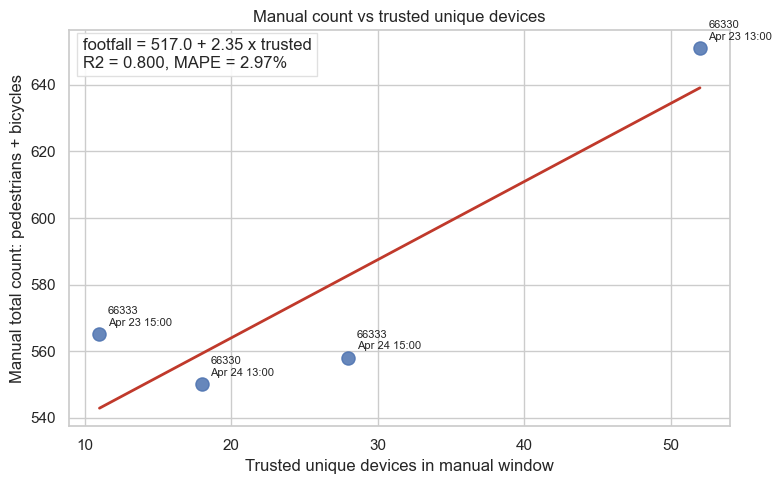

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=calibration_df,
    x="trusted_unique_devices",
    y="manual_total_count",
    ci=None,
    scatter_kws={"s": 90, "alpha": 0.85},
    line_kws={"color": "#c0392b", "linewidth": 2},
    ax=ax,
)

for row in calibration_df.itertuples(index=False):
    label = f"{int(row.facility_num)}\n{pd.Timestamp(row.started).strftime('%b %d %H:%M')}"
    ax.annotate(
        label,
        (row.trusted_unique_devices, row.manual_total_count),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
    )

ax.set_title("Manual count vs trusted unique devices")
ax.set_xlabel("Trusted unique devices in manual window")
ax.set_ylabel("Manual total count: pedestrians + bicycles")
ax.text(
    0.02,
    0.98,
    f"footfall = {calibration_result.intercept:.1f} + {calibration_result.slope:.2f} x trusted\n"
    f"R2 = {calibration_result.r2:.3f}, MAPE = {calibration_result.mape * 100:.2f}%",
    transform=ax.transAxes,
    va="top",
    bbox={"facecolor": "white", "edgecolor": "#dddddd", "alpha": 0.9},
)
plt.tight_layout()
plt.show()

## Compare Candidate Sensor Signals

A useful EDA step is to compare trusted devices against other features. Trusted devices may correlate well with manual counts, but they are a tiny subset of the traffic because modern devices often use randomized/local MAC addresses.

In [14]:
feature_cols = [
    "raw_unique_devices",
    "clean_unique_devices",
    "raw_sessions",
    "clean_sessions",
    "trusted_unique_devices",
    "local_unique_devices",
    "mean_signal_level",
    "median_session_duration",
]

corr_rows = []
for feature in feature_cols:
    corr_rows.append(
        {
            "feature": feature,
            "corr_manual_total": calibration_df[feature].corr(calibration_df["manual_total_count"]),
            "corr_manual_pedestrians": calibration_df[feature].corr(calibration_df["manual_pedestrian_count"]),
        }
    )

correlations = pd.DataFrame(corr_rows)
correlations["abs_corr_manual_total"] = correlations["corr_manual_total"].abs()
correlations = correlations.sort_values("abs_corr_manual_total", ascending=False)
display(correlations)

,feature,corr_manual_total,corr_manual_pedestrians,abs_corr_manual_total
4,trusted_unique_devices,0.894,0.832,0.894
5,local_unique_devices,0.728,0.480,0.728
1,clean_unique_devices,0.728,0.480,0.728
0,raw_unique_devices,0.728,0.479,0.728
3,clean_sessions,0.727,0.478,0.727
2,raw_sessions,0.726,0.478,0.726
6,mean_signal_level,-0.198,0.063,0.198
7,median_session_duration,NaN,NaN,NaN


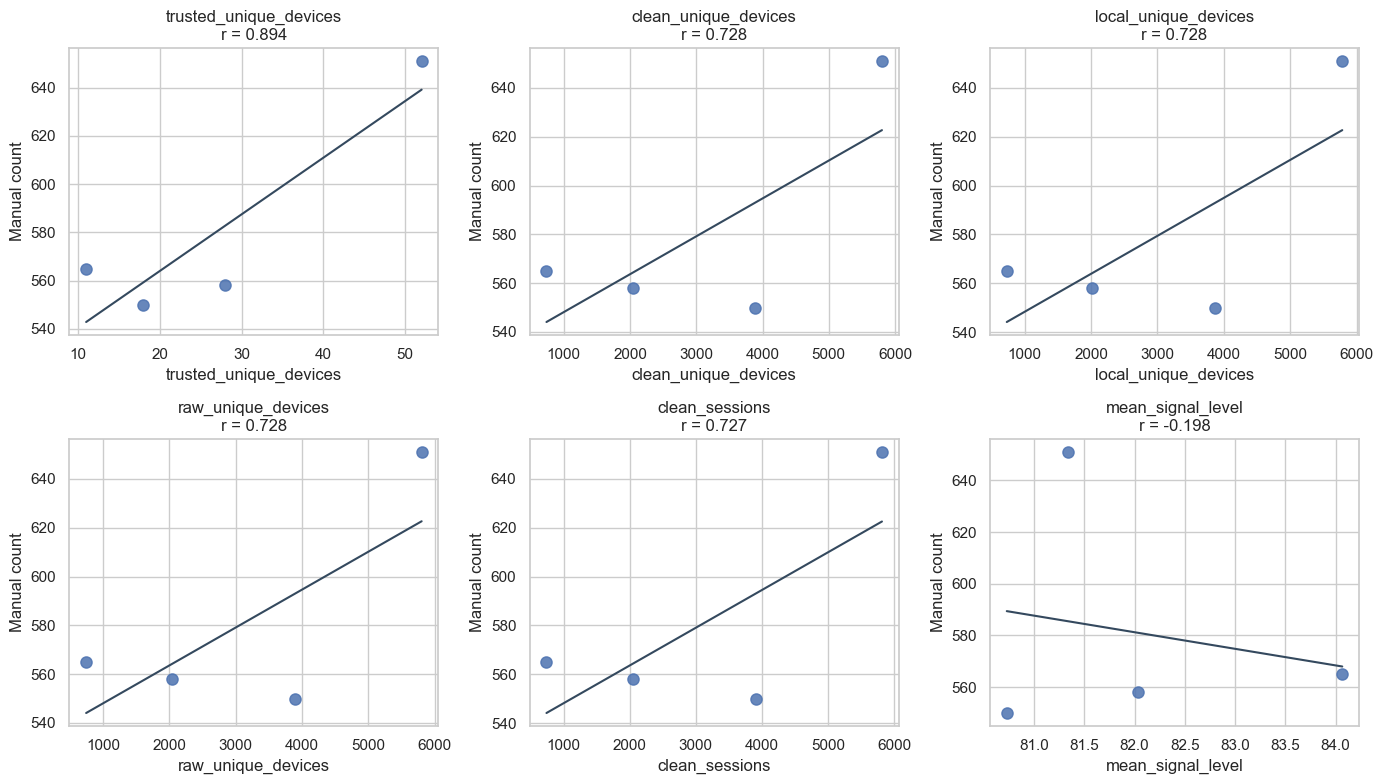

In [7]:
plot_features = [
    "trusted_unique_devices",
    "clean_unique_devices",
    "local_unique_devices",
    "raw_unique_devices",
    "clean_sessions",
    "mean_signal_level",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feature in zip(axes.ravel(), plot_features):
    sns.regplot(
        data=calibration_df,
        x=feature,
        y="manual_total_count",
        ci=None,
        scatter_kws={"s": 65, "alpha": 0.85},
        line_kws={"color": "#34495e", "linewidth": 1.5},
        ax=ax,
    )
    corr = calibration_df[feature].corr(calibration_df["manual_total_count"])
    ax.set_title(f"{feature}\nr = {corr:.3f}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Manual count")

plt.tight_layout()
plt.show()

## Simple Model Comparison

This is not a final modelling exercise. It is a quick diagnostic to see how each single feature behaves on the same four manual windows.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

model_rows = []
y = calibration_df["manual_total_count"].to_numpy()

for feature in [
    "trusted_unique_devices",
    "clean_unique_devices",
    "local_unique_devices",
    "raw_unique_devices",
    "clean_sessions",
]:
    x = calibration_df[[feature]].to_numpy()
    model = LinearRegression().fit(x, y)
    pred = np.clip(model.predict(x), 0, None)
    model_rows.append(
        {
            "feature": feature,
            "intercept": model.intercept_,
            "slope": model.coef_[0],
            "mae": mean_absolute_error(y, pred),
            "mape_pct": mean_absolute_percentage_error(y, pred) * 100,
            "r2": r2_score(y, pred),
        }
    )

model_comparison = pd.DataFrame(model_rows).sort_values("mape_pct")
display(model_comparison)

,feature,intercept,slope,mae,mape_pct,r2
0,trusted_unique_devices,516.976,2.350,17.015,2.967,0.800
2,local_unique_devices,532.762,0.016,24.582,4.241,0.530
1,clean_unique_devices,532.595,0.016,24.620,4.247,0.530
3,raw_unique_devices,532.541,0.016,24.633,4.249,0.529
4,clean_sessions,532.709,0.015,24.660,4.254,0.528


## Weekly Trend: Trusted Devices in Context

Now inspect whether trusted devices move with total clean devices across the week. If trusted devices are stable but too sparse, they can be useful as a calibration anchor but risky as the only footfall driver.

In [16]:
clean_sessions = sessions.loc[build_quality_mask(sessions)].copy()

daily_clean = (
    clean_sessions.groupby("date", as_index=False)
    .agg(clean_sessions=("device_id", "size"), clean_unique_devices=("device_id", "nunique"))
)
daily_trusted = (
    clean_sessions.loc[clean_sessions["is_trusted"]]
    .groupby("date")["device_id"]
    .nunique()
    .rename("trusted_unique_devices")
)
daily_local = (
    clean_sessions.loc[clean_sessions["is_local"]]
    .groupby("date")["device_id"]
    .nunique()
    .rename("local_unique_devices")
)
daily = (
    daily_clean.merge(daily_trusted, on="date", how="left")
    .merge(daily_local, on="date", how="left")
    .fillna(0)
)
daily["trusted_share_of_clean_unique_pct"] = (
    daily["trusted_unique_devices"] / daily["clean_unique_devices"].clip(lower=1) * 100
)

display(daily)

,date,clean_sessions,clean_unique_devices,trusted_unique_devices,local_unique_devices,trusted_share_of_clean_unique_pct
0,2026-04-20,270265,252782,1834,252052,0.726
1,2026-04-21,169714,155877,1438,155024,0.923
2,2026-04-22,276625,255219,1932,254476,0.757
3,2026-04-23,250575,235150,2122,234399,0.902
4,2026-04-24,338396,313237,2457,312406,0.784
5,2026-04-25,509503,465724,2688,464969,0.577
6,2026-04-26,422768,382113,2283,381549,0.597


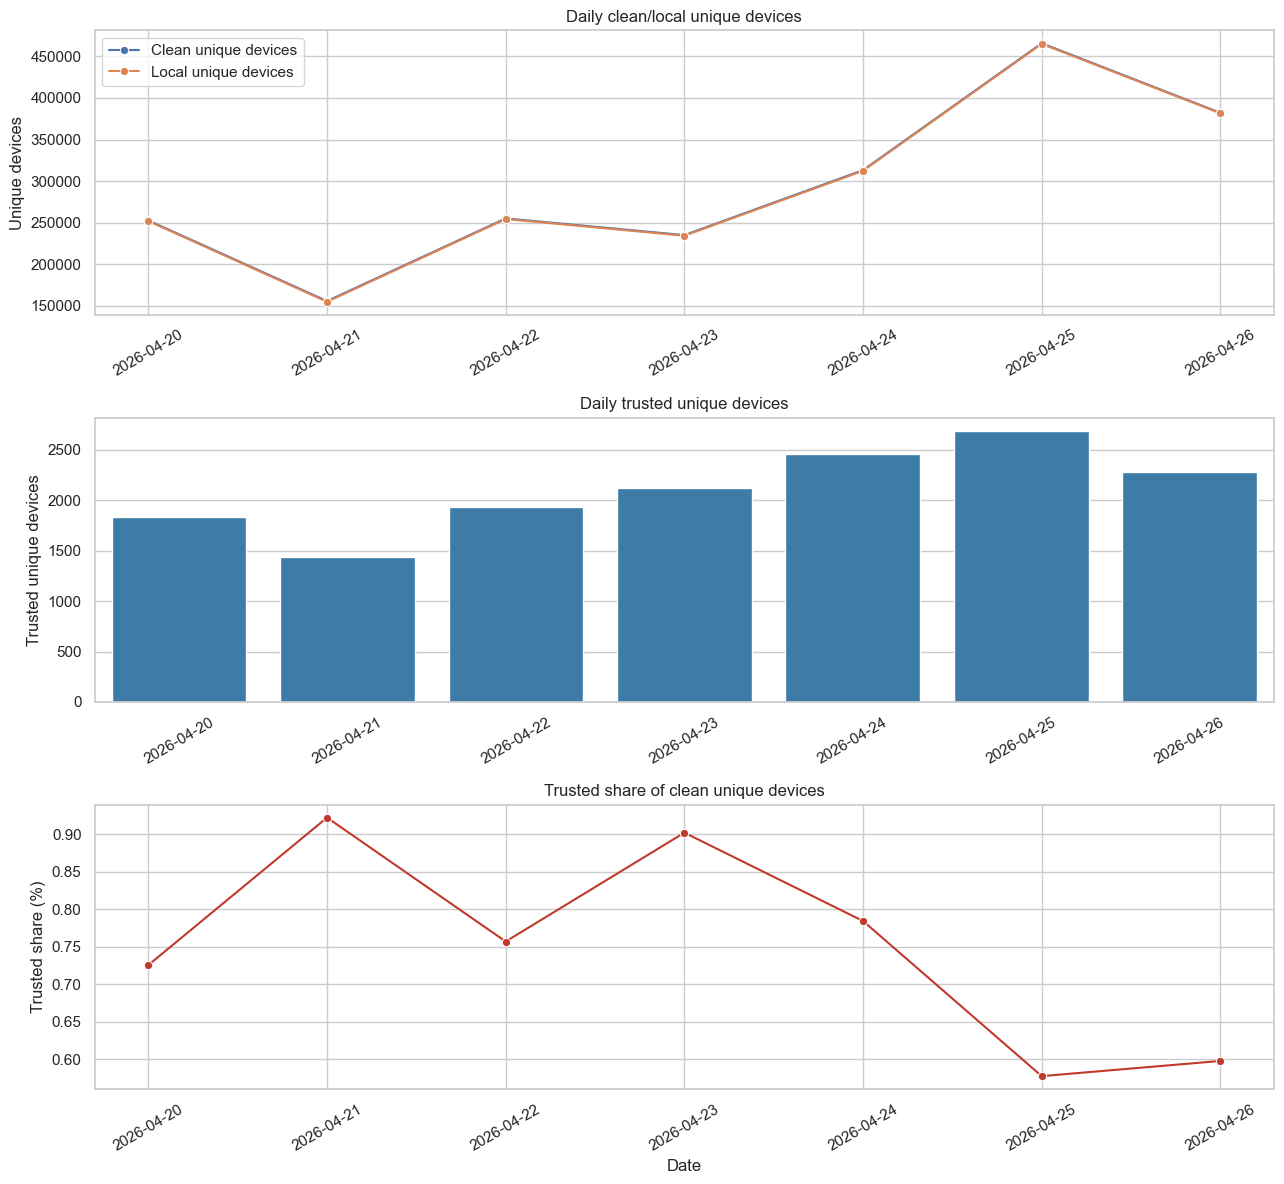

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=False)

sns.lineplot(data=daily, x="date", y="clean_unique_devices", marker="o", label="Clean unique devices", ax=axes[0])
sns.lineplot(data=daily, x="date", y="local_unique_devices", marker="o", label="Local unique devices", ax=axes[0])
axes[0].set_title("Daily clean/local unique devices")
axes[0].set_xlabel("")
axes[0].set_ylabel("Unique devices")
axes[0].legend()

sns.barplot(data=daily, x="date", y="trusted_unique_devices", color="#2c7fb8", ax=axes[1])
axes[1].set_title("Daily trusted unique devices")
axes[1].set_xlabel("")
axes[1].set_ylabel("Trusted unique devices")

sns.lineplot(data=daily, x="date", y="trusted_share_of_clean_unique_pct", marker="o", color="#c0392b", ax=axes[2])
axes[2].set_title("Trusted share of clean unique devices")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Trusted share (%)")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Hourly and Sensor-Level Trusted Trends

A weekly model should understand time-of-day and sensor location. These plots show where trusted-device activity is concentrated.

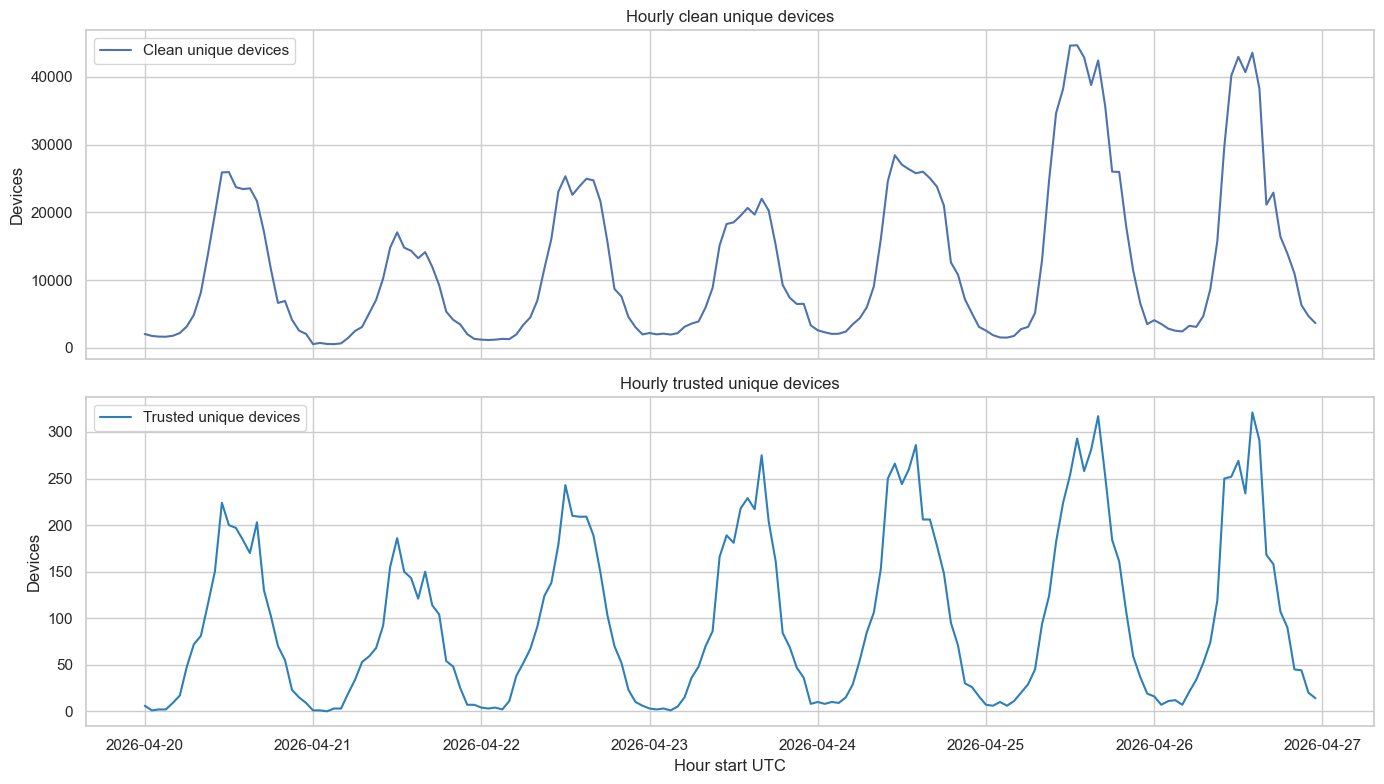

In [17]:
hourly_clean = (
    clean_sessions.groupby("hour_start", as_index=False)
    .agg(clean_unique_devices=("device_id", "nunique"), clean_sessions=("device_id", "size"))
)
hourly_trusted = (
    clean_sessions.loc[clean_sessions["is_trusted"]]
    .groupby("hour_start")["device_id"]
    .nunique()
    .rename("trusted_unique_devices")
)
hourly = hourly_clean.merge(hourly_trusted, on="hour_start", how="left").fillna(0)
hourly["trusted_share_pct"] = hourly["trusted_unique_devices"] / hourly["clean_unique_devices"].clip(lower=1) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=hourly, x="hour_start", y="clean_unique_devices", ax=axes[0], label="Clean unique devices")
axes[0].set_title("Hourly clean unique devices")
axes[0].set_ylabel("Devices")

sns.lineplot(data=hourly, x="hour_start", y="trusted_unique_devices", ax=axes[1], color="#2c7fb8", label="Trusted unique devices")
axes[1].set_title("Hourly trusted unique devices")
axes[1].set_ylabel("Devices")
axes[1].set_xlabel("Hour start UTC")

plt.tight_layout()
plt.show()

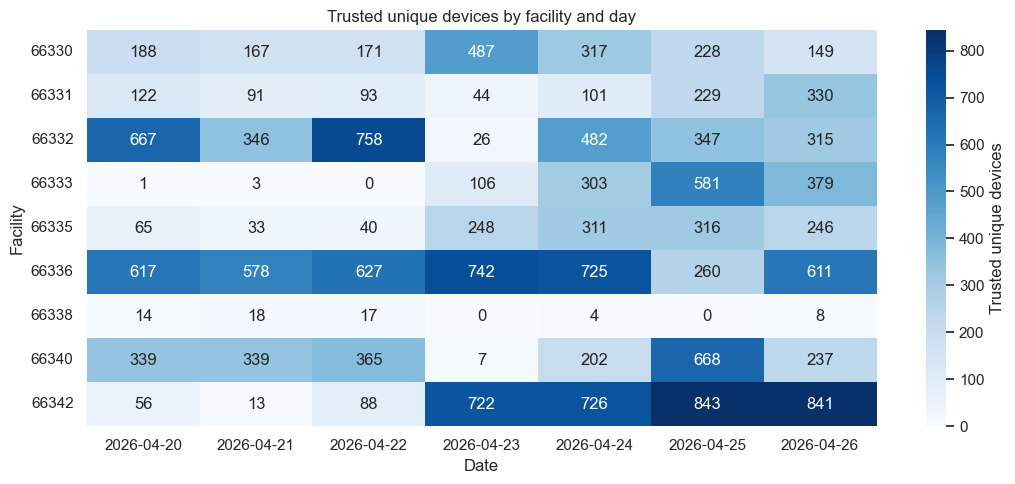

In [18]:
sensor_daily_clean = (
    clean_sessions.groupby(["date", "facility_num"], as_index=False)["device_id"]
    .nunique()
    .rename(columns={"device_id": "clean_unique_devices"})
)
sensor_daily_trusted = (
    clean_sessions.loc[clean_sessions["is_trusted"]]
    .groupby(["date", "facility_num"], as_index=False)["device_id"]
    .nunique()
    .rename(columns={"device_id": "trusted_unique_devices"})
)

sensor_daily = (
    sensor_daily_clean.merge(sensor_daily_trusted, on=["date", "facility_num"], how="left")
    .fillna({"trusted_unique_devices": 0})
)

trusted_pivot = sensor_daily.pivot_table(
    index="facility_num", columns="date", values="trusted_unique_devices", aggfunc="sum", fill_value=0
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(trusted_pivot, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "Trusted unique devices"}, ax=ax)
ax.set_title("Trusted unique devices by facility and day")
ax.set_xlabel("Date")
ax.set_ylabel("Facility")
plt.tight_layout()
plt.show()

## Feature Ideas for Improving the Tasks

This section builds an exploratory hourly feature frame. It is not a final model input yet, but it shows the type of explanatory variables worth testing next.

In [19]:
hourly_features = (
    clean_sessions.groupby(["facility_num", "hour_start"], as_index=False)
    .agg(
        clean_sessions=("device_id", "size"),
        clean_unique_devices=("device_id", "nunique"),
        mean_signal_level=("signal_level", "mean"),
        median_signal_level=("signal_level", "median"),
        median_session_duration=("session_duration", "median"),
        zero_duration_ratio=("session_duration", lambda s: (s == 0).mean()),
    )
)

# Compute trusted/local unique devices with explicit masks for clarity.
trusted_hourly = (
    clean_sessions.loc[clean_sessions["is_trusted"]]
    .groupby(["facility_num", "hour_start"], as_index=False)["device_id"]
    .nunique()
    .rename(columns={"device_id": "trusted_unique_devices_checked"})
)
local_hourly = (
    clean_sessions.loc[clean_sessions["is_local"]]
    .groupby(["facility_num", "hour_start"], as_index=False)["device_id"]
    .nunique()
    .rename(columns={"device_id": "local_unique_devices"})
)
hourly_features = (
    hourly_features.merge(trusted_hourly, on=["facility_num", "hour_start"], how="left")
    .merge(local_hourly, on=["facility_num", "hour_start"], how="left")
    .fillna({"trusted_unique_devices_checked": 0, "local_unique_devices": 0})
    .rename(columns={"trusted_unique_devices_checked": "trusted_unique_devices"})
)
hourly_features["hour_of_day"] = hourly_features["hour_start"].dt.hour
hourly_features["date"] = hourly_features["hour_start"].dt.date
hourly_features["trusted_share_pct"] = hourly_features["trusted_unique_devices"] / hourly_features["clean_unique_devices"].clip(lower=1) * 100

display(hourly_features.head(10))

,facility_num,hour_start,clean_sessions,clean_unique_devices,mean_signal_level,median_signal_level,median_session_duration,zero_duration_ratio,trusted_unique_devices,local_unique_devices,hour_of_day,date,trusted_share_pct
0,66330,2026-04-20 00:00:00+00:00,143,142,83.287,84.000,0.000,0.881,0.000,142.000,0,2026-04-20,0.000
1,66330,2026-04-20 01:00:00+00:00,75,72,82.720,84.000,0.000,0.800,0.000,71.000,1,2026-04-20,0.000
2,66330,2026-04-20 02:00:00+00:00,111,111,78.811,81.000,0.000,0.775,0.000,110.000,2,2026-04-20,0.000
3,66330,2026-04-20 03:00:00+00:00,115,114,78.652,79.000,0.000,0.809,0.000,112.000,3,2026-04-20,0.000
4,66330,2026-04-20 04:00:00+00:00,139,135,81.043,82.000,0.000,0.892,0.000,135.000,4,2026-04-20,0.000
5,66330,2026-04-20 05:00:00+00:00,233,233,80.790,81.000,0.000,0.871,3.000,230.000,5,2026-04-20,1.288
6,66330,2026-04-20 06:00:00+00:00,647,646,81.057,82.000,0.000,0.898,11.000,638.000,6,2026-04-20,1.703
7,66330,2026-04-20 07:00:00+00:00,847,842,81.604,83.000,0.000,0.887,8.000,837.000,7,2026-04-20,0.950
8,66330,2026-04-20 08:00:00+00:00,1283,1277,81.230,82.000,0.000,0.929,6.000,"1,260.000",8,2026-04-20,0.470
9,66330,2026-04-20 09:00:00+00:00,2173,2164,81.259,82.000,0.000,0.932,15.000,"2,147.000",9,2026-04-20,0.693


## EDA Takeaways and Next Improvements

Use this as the checklist before improving each assignment task:

1. Task 1: test trusted devices against clean/local devices, signal-strength summaries, zero-duration share, and hour-of-day features. Avoid trusting the four-point in-sample fit too much. Try no-intercept, regularized, and capture-rate models.
2. Task 1: add uncertainty. With four manual windows, leave-one-out error and bootstrap intervals matter more than raw in-sample MAPE.
3. Task 2: split overlap by day and hour. Pairwise overlap may mean movement, sensor proximity, or repeated background devices.
4. Task 3: export the full journey table, not only top paths and samples. Add max-time-gap rules so one device seen hours apart is not automatically treated as a continuous journey.
5. Task 4: compare built-in flags against independent patterns: high session count, high night ratio, impossible movement, unusual signal distributions, and hour-of-day residuals.

The most important modelling question from this notebook is whether `trusted_unique_devices` is a reliable calibration signal or only a small but convenient proxy.